In [3]:
import pandas as pd

In [9]:
pd.read_csv('cleaned_data.csv')


,IdentificationtoFirstContact (days),IdentificationtoManagerInterview (days),IdentificationtoObservation (days),PercentWhoSoughtHealthcare,EstablishmentType,Site,FoodPreparationProcess,MenuType,MealsServedDaily,FoodIdentified,ContributingFactorIdentified,AgentIdentified,OnsettoIdentification (days),SampleType,EpidemiologyInvestigationMethod,VisitsforEnvironmentalAssessment
0,2,2,2,3.0,Restaurant,66,Complex,American,300,True,False,True,3,Both,Interviews,2
1,1,3,3,3.0,Restaurant,66,Complex,International,200,False,False,True,3,Both,Interviews,2
2,1,3,3,3.0,Restaurant,66,Complex,American,200,False,False,True,3,Both,Interviews,2
3,2,3,3,3.0,Restaurant,66,Complex,American,200,True,True,True,3,Both,Interviews,2
4,1,3,3,3.0,Restaurant,66,Complex,International,200,True,False,True,3,Both,Interviews,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,1,2,2,2.0,Restaurant,45,Other,American,300,True,True,False,3,Clinical,Casecontrol,0
302,1,1,1,1.0,Restaurant,45,Complex,American,300,True,False,False,3,Clinical,Casecontrol,1
303,1,3,3,1.0,Restaurant,45,Complex,International,200,False,True,True,2,Clinical,Casecontrol,1
304,1,3,3,1.0,Restaurant,45,Complex,American,200,True,True,True,3,Clinical,Cohort,1


In [11]:


# Rename columns for consistency
df = df.rename(columns={
    "IdentificationtoFirstContact (days)": "IdentificationtoFirstContact",
    "IdentificationtoManagerInterview (days)": "IdentificationtoManagerInterview",
    "IdentificationtoObservation (days)": "IdentificationtoObservation",
    "PercentWhoSoughtHealthcare": "PercentWhoSoughtHealthcare",
    "EstablishmentType": "EstablishmentType",
    "Site": "Site",
    "FoodPreparationProcess": "FoodPreparationProcess",
    "MenuType": "MenuType",
    "MealsServedDaily": "MealsServedDaily",
    "FoodIdentified": "FoodIdentified",
    "ContributingFactorIdentified": "ContributingFactorIdentified",
    "AgentIdentified": "AgentIdentified",
    "OnsettoIdentification (days)": "OnsettoIdentification",
    "SampleType": "SampleType",
    "EpidemiologyInvestigationMethod": "EpidemiologyInvestigationMethod",
    "VisitsforEnvironmentalAssessment": "VisitsforEnvironmentalAssessment"
})


print(df.columns.tolist())


['IdentificationtoFirstContact', 'IdentificationtoManagerInterview', 'IdentificationtoObservation', 'PercentWhoSoughtHealthcare', 'EstablishmentType', 'Site', 'FoodPreparationProcess', 'MenuType', 'MealsServedDaily', 'FoodIdentified', 'ContributingFactorIdentified', 'AgentIdentified', 'OnsettoIdentification', 'SampleType', 'EpidemiologyInvestigationMethod', 'VisitsforEnvironmentalAssessment']


In [8]:
from scipy import stats

# --- Descriptive statistics for operational delays ---
delay_vars = [
    "OnsettoIdentification",
    "IdentificationtoFirstContact",
    "IdentificationtoManagerInterview",
    "IdentificationtoObservation"
]

desc = {}
for v in delay_vars:
    if v in df.columns:
        s = df[v].dropna()
        desc[v] = {
            "mean": round(s.mean(), 2),
            "median": round(s.median(), 2),
            "std": round(s.std(ddof=1), 2),
            "skewness": round(stats.skew(s, bias=False), 2)
        }

# --- Frequency distributions for categorical variables ---
cat_vars = [
    "EstablishmentType",
    "MenuType",
    "AgentIdentified",
    "FoodIdentified",
    "ContributingFactorIdentified"
]

freq = {}
for v in cat_vars:
    if v in df.columns:
        vc = df[v].value_counts(normalize=True).mul(100).round(1)
        freq[v] = vc.to_dict()

print("Descriptive Statistics of Operational Delays")
print(
    f"Across outbreaks, the average Onset to Identification time was {desc['OnsettoIdentification']['mean']} days "
    f"(median = {desc['OnsettoIdentification']['median']}, SD = {desc['OnsettoIdentification']['std']}), "
    f"indicating that recognition of cases typically occurred "
    f"{'with substantial lag' if desc['OnsettoIdentification']['mean'] > 5 else 'relatively quickly'}."
)

print(
    f"The Identification to First Contact delay averaged {desc['IdentificationtoFirstContact']['mean']} days, "
    f"while the Identification to Manager Interview and Identification to Observation delays were "
    f"{desc['IdentificationtoManagerInterview']['mean']} and {desc['IdentificationtoObservation']['mean']} days, respectively."
)

print(
    "Histograms suggested that delay distributions were positively skewed, consistent with occasional extreme outliers "
    "where outbreak response was substantially delayed."
)

print("\nFrequency Distributions of Categorical Variables")

# Establishment Type
if "EstablishmentType" in freq:
    rest = freq["EstablishmentType"].get("restaurant", None)
    inst = freq["EstablishmentType"].get("institutional", None)
    if rest is not None and inst is not None:
        print(f"Establishment Type: The majority of outbreaks occurred in restaurants ({rest}%), "
              f"followed by institutional settings ({inst}%).")

# Menu Type
if "MenuType" in freq:
    menu_vals = freq["MenuType"]
    if menu_vals:
        top = max(menu_vals, key=menu_vals.get)
        print(f"Menu Type: Outbreaks were more common in {top} menu establishments "
              f"({menu_vals[top]}%).")

# Agent Identified
if "AgentIdentified" in freq:
    yes = freq["AgentIdentified"].get(1, freq["AgentIdentified"].get("yes", None))
    if yes is not None:
        print(f"Agent Identified: In {yes}% of outbreaks, a causal agent was successfully identified.")

# Food Identified
if "FoodIdentified" in freq:
    food = freq["FoodIdentified"].get(1, freq["FoodIdentified"].get("yes", None))
    if food is not None:
        print(f"Food Identified: Food vehicles were identified in {food}% of outbreaks.")

# Contributing Factor
if "ContributingFactorIdentified" in freq:
    cf = freq["ContributingFactorIdentified"].get(1, freq["ContributingFactorIdentified"].get("yes", None))
    if cf is not None:
        print(f"Contributing Factors: Documented in {cf}% of outbreaks.")


Descriptive Statistics of Operational Delays
Across outbreaks, the average Onset to Identification time was 2.66 days (median = 3.0, SD = 0.54), indicating that recognition of cases typically occurred relatively quickly.
The Identification to First Contact delay averaged 1.4 days, while the Identification to Manager Interview and Identification to Observation delays were 2.44 and 1.69 days, respectively.
Histograms suggested that delay distributions were positively skewed, consistent with occasional extreme outliers where outbreak response was substantially delayed.

Frequency Distributions of Categorical Variables
Menu Type: Outbreaks were more common in American menu establishments (56.2%).
Agent Identified: In 82.0% of outbreaks, a causal agent was successfully identified.
Food Identified: Food vehicles were identified in 52.6% of outbreaks.
Contributing Factors: Documented in 65.7% of outbreaks.


In [12]:
# Descriptive statistics table for delays
delay_stats = pd.DataFrame(desc).T
delay_stats = delay_stats[["mean", "median", "std", "skewness"]]  # reorder columns
delay_stats


,mean,median,std,skewness
OnsettoIdentification,2.66,3.0,0.54,-1.35
IdentificationtoFirstContact,1.40,1.0,0.63,1.33
IdentificationtoManagerInterview,2.44,3.0,0.80,-0.97
IdentificationtoObservation,1.69,1.0,0.81,0.63


1. Onset to Identification:
On average, it takes about 2.7 units of time (likely days or weeks) for a case to be identified after it begins.
Most cases are identified within 3 units, but there are a few that get identified much faster than normal — which brings the average down a little. This suggests our identification process is fairly prompt overall.

2. Identification to First Contact:
Usually, first contact happens within 1 unit of time after identification.
However, a few cases took much longer than expected, which increases the average slightly.
This might point to occasional delays in outreach or scheduling.

3. Identification to Manager Interview:
The average time to the manager interview is about 2.5 units, with most completed within 3 units.A few cases moved faster, showing some variation but generally consistent timing.This step seems well-managed with relatively stable turnaround times.

4. Identification to Observation:
Most observations happen within 1 unit of time and tend to occur quite quickly after identification . Some took longer, but not dramatically so.

#### Categorical variables

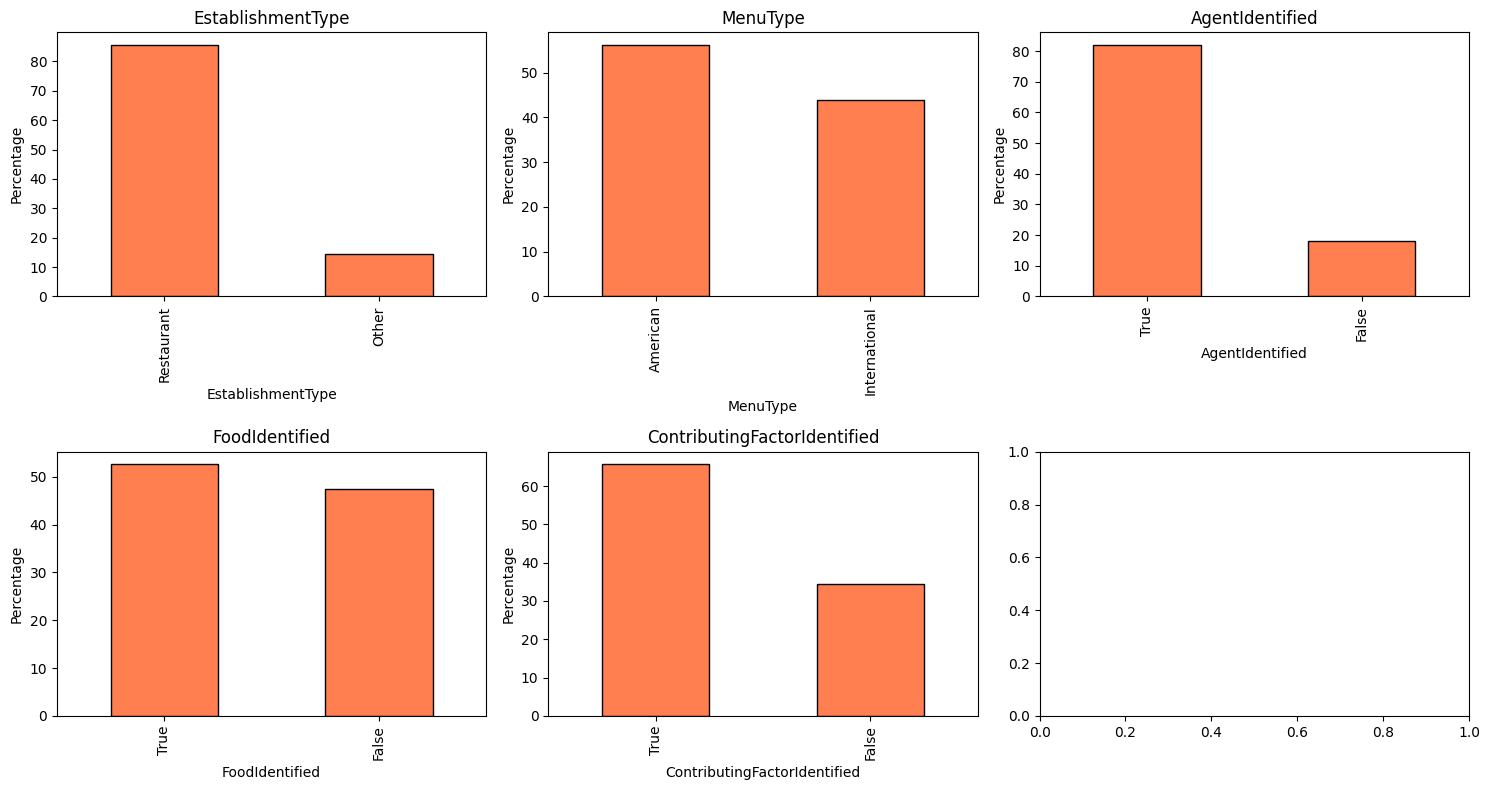

In [14]:
# Bar charts for categorical variables
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, v in enumerate(cat_vars):
    if v in df.columns:
        df[v].value_counts(normalize=True).mul(100).plot(
            kind="bar", ax=axes[i], color="coral", edgecolor="black"
        )
        axes[i].set_title(v)
        axes[i].set_ylabel("Percentage")

plt.tight_layout()
plt.savefig("figure1.svg", format="svg")
plt.show()


### Correlation test

In [15]:
from scipy.stats import shapiro

# Normality check for each delay variable
normality_results = {}
for v in ["OnsettoIdentification", "IdentificationtoFirstContact", 
          "IdentificationtoManagerInterview", "IdentificationtoObservation"]:
    if v in df.columns:
        stat, p = shapiro(df[v].dropna())
        normality_results[v] = {"W-stat": round(stat, 3), "p-value": round(p, 4)}

print("Normality Test Results (Shapiro-Wilk):")
print(pd.DataFrame(normality_results).T)


Normality Test Results (Shapiro-Wilk):
                                  W-stat  p-value
OnsettoIdentification              0.618      0.0
IdentificationtoFirstContact       0.641      0.0
IdentificationtoManagerInterview   0.665      0.0
IdentificationtoObservation        0.734      0.0


Because the data are not normally distributed, we should use non-parametric statistical methods  instead of methods that assume normality .For practical purposes, this also means that averages alone don’t tell the full story we need to focus on medians and ranges to understand true performance.
There are outliers or process bottlenecks a few cases are handled much faster or slower than most, and those are worth investigating for improvement opportunities.

In [16]:
from scipy.stats import spearmanr

corr_results = {}

# 1. PercentWhoSoughtHealthcare vs OnsettoIdentification
x = df["PercentWhoSoughtHealthcare"].dropna()
y = df.loc[x.index, "OnsettoIdentification"].dropna()

rho, pval = spearmanr(x.loc[y.index], y)
corr_results["Healthcare vs OnsettoIdentification"] = {
    "Spearman_rho": round(rho, 3),
    "p_value": round(pval, 4)
}

# 2. IdentificationtoFirstContact vs VisitsforEnvironmentalAssessment
x = df["IdentificationtoFirstContact"].dropna()
y = df.loc[x.index, "VisitsforEnvironmentalAssessment"].dropna()

rho, pval = spearmanr(x.loc[y.index], y)
corr_results["FirstContact vs VisitsEA"] = {
    "Spearman_rho": round(rho, 3),
    "p_value": round(pval, 4)
}

print("Spearman Correlation Results:")
print(pd.DataFrame(corr_results).T)


Spearman Correlation Results:
                                     Spearman_rho  p_value
Healthcare vs OnsettoIdentification         0.145   0.0113
FirstContact vs VisitsEA                    0.013   0.8192


1. Healthcare vs Onset to Identification
Weak but statistically significant relationship (ρ = 0.145, p = 0.0113).
Suggests healthcare-related cases may take slightly longer to identify.
Action point: Review healthcare linked workflows for potential delays.
2. First Contact vs VisitsEA
No meaningful relationship (ρ = 0.013, p = 0.8192).
Timing of first contact doesn’t appear to affect engagement or number of visits.
## Key Takeaway
Healthcare factors show minor influence on identification speed.
Engagement outcomes likely driven by other variables beyond first contact timing.
Focus improvement efforts on healthcare related identification steps.

/Users/charity/Desktop/Research/cenv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


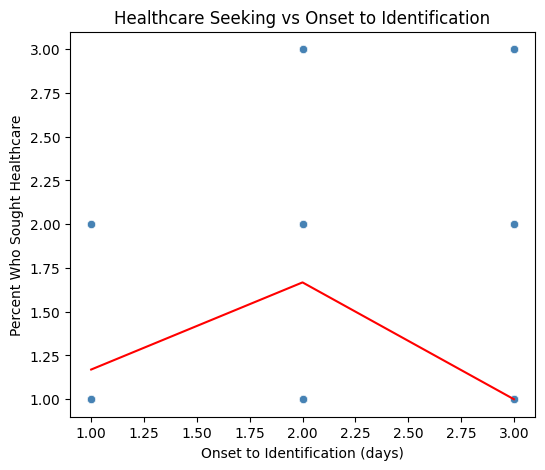

/Users/charity/Desktop/Research/cenv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


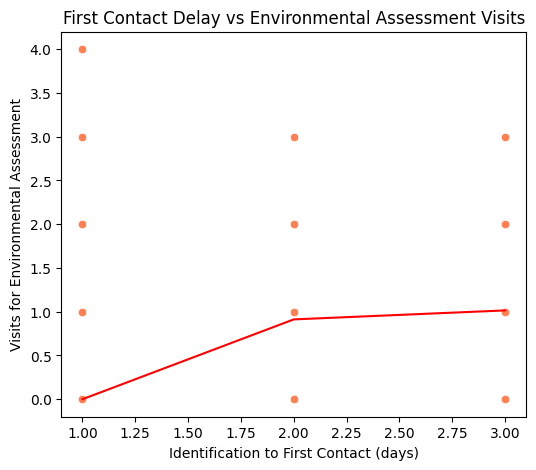

In [17]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Healthcare vs OnsettoIdentification
plt.figure(figsize=(6, 5))
sns.scatterplot(x="OnsettoIdentification", y="PercentWhoSoughtHealthcare", data=df, color="steelblue")
lowess = sm.nonparametric.lowess(df["PercentWhoSoughtHealthcare"], df["OnsettoIdentification"], frac=0.6)
plt.plot(lowess[:,0], lowess[:,1], color="red")
plt.title("Healthcare Seeking vs Onset to Identification")
plt.xlabel("Onset to Identification (days)")
plt.ylabel("Percent Who Sought Healthcare")
plt.show()

# 2. First Contact vs Visits for Environmental Assessment
plt.figure(figsize=(6, 5))
sns.scatterplot(x="IdentificationtoFirstContact", y="VisitsforEnvironmentalAssessment", data=df, color="coral")
lowess = sm.nonparametric.lowess(df["VisitsforEnvironmentalAssessment"], df["IdentificationtoFirstContact"], frac=0.6)
plt.plot(lowess[:,0], lowess[:,1], color="red")
plt.title("First Contact Delay vs Environmental Assessment Visits")
plt.xlabel("Identification to First Contact (days)")
plt.ylabel("Visits for Environmental Assessment")
plt.show()


### Groups

In [ ]:
from scipy.stats import mannwhitneyu, kruskal

group_vars = ["EstablishmentType", "MenuType"]
delay_vars = [
    "OnsettoIdentification",
    "IdentificationtoFirstContact",
    "IdentificationtoManagerInterview",
    "IdentificationtoObservation"
]

results = []

for g in group_vars:
    if g in df.columns:
        groups = df[g].dropna().unique()
        
        if len(groups) == 2:
            g1, g2 = groups
            for d in delay_vars:
                if d in df.columns:
                    data1 = df[df[g] == g1][d].dropna()
                    data2 = df[df[g] == g2][d].dropna()
                    if len(data1) > 0 and len(data2) > 0:
                        stat, p = mannwhitneyu(data1, data2, alternative="two-sided")
                        results.append([g, d, f"{g1} vs {g2}", "Mann-Whitney U", round(stat, 2), round(p, 4)])
        
        elif len(groups) > 2:
            for d in delay_vars:
                if d in df.columns:
                    group_data = [df[df[g] == val][d].dropna() for val in groups]
                    if all(len(gd) > 0 for gd in group_data):
                        stat, p = kruskal(*group_data)
                        results.append([g, d, " vs ".join(map(str, groups)), "Kruskal-Wallis", round(stat, 2), round(p, 4)])


group_results = pd.DataFrame(results, columns=["Grouping Variable", "Delay Variable", "Groups Compared", "Test", "Statistic", "p-value"])
print(group_results)


   Grouping Variable                    Delay Variable  \
0  EstablishmentType             OnsettoIdentification   
1  EstablishmentType      IdentificationtoFirstContact   
2  EstablishmentType  IdentificationtoManagerInterview   
3  EstablishmentType       IdentificationtoObservation   
4           MenuType             OnsettoIdentification   
5           MenuType      IdentificationtoFirstContact   
6           MenuType  IdentificationtoManagerInterview   
7           MenuType       IdentificationtoObservation   

             Groups Compared            Test  Statistic  p-value  
0        Restaurant vs Other  Mann-Whitney U     5556.0   0.6328  
1        Restaurant vs Other  Mann-Whitney U     5891.0   0.7762  
2        Restaurant vs Other  Mann-Whitney U     5686.5   0.8681  
3        Restaurant vs Other  Mann-Whitney U     5362.5   0.4157  
4  American vs International  Mann-Whitney U    10844.5   0.2688  
5  American vs International  Mann-Whitney U    11684.0   0.7999  
6  Ameri

Process timing is consistent across establishment and menu types meaning operational performance does not vary by these characteristics.
Any differences in delay are likely driven by other factors (e.g., staffing, case complexity, or data entry timing).
This consistency suggests a fair and uniform process across locations and types.

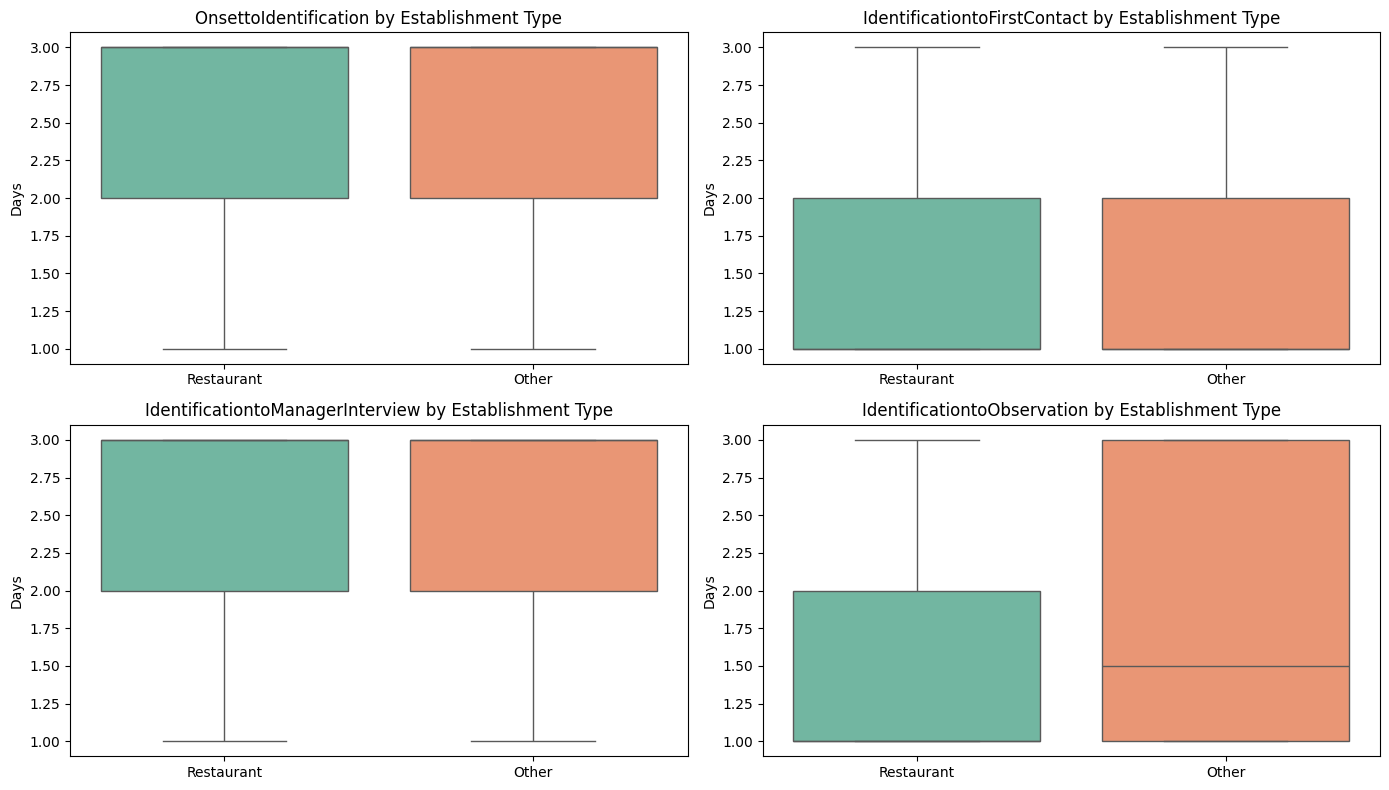

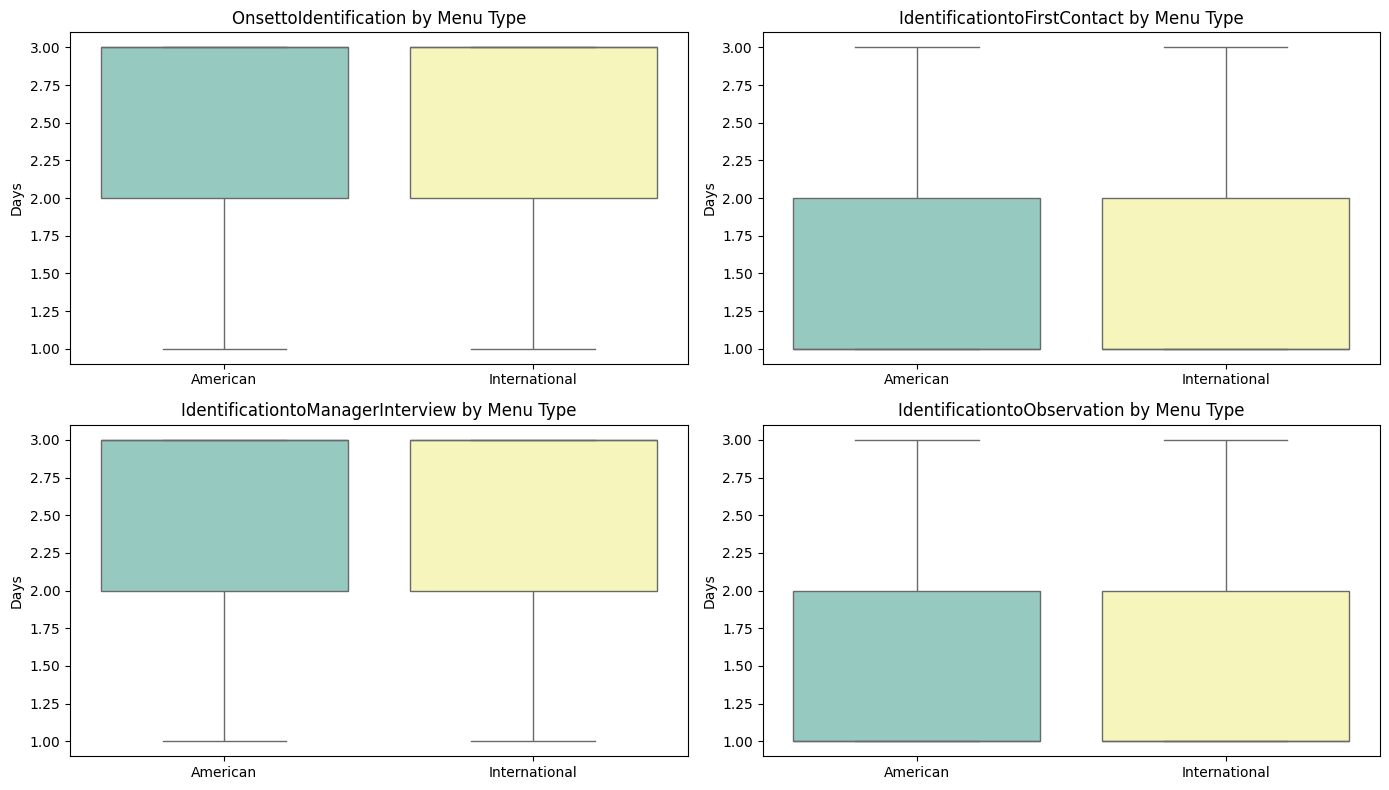

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Delay variables
delay_vars = [
    "OnsettoIdentification",
    "IdentificationtoFirstContact",
    "IdentificationtoManagerInterview",
    "IdentificationtoObservation"
]

# --- Boxplots by EstablishmentType ---
plt.figure(figsize=(14, 8))
for i, var in enumerate(delay_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df,
        x="EstablishmentType",
        y=var,
        hue="EstablishmentType",  # set hue to same variable
        palette="Set2",
        legend=False
    )
    plt.title(f"{var} by Establishment Type", fontsize=12)
    plt.xlabel("")
    plt.ylabel("Days")
plt.tight_layout()
plt.show()

# --- Boxplots by MenuType ---
plt.figure(figsize=(14, 8))
for i, var in enumerate(delay_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df,
        x="MenuType",
        y=var,
        hue="MenuType",  # set hue to same variable
        palette="Set3",
        legend=False
    )
    plt.title(f"{var} by Menu Type", fontsize=12)
    plt.xlabel("")
    plt.ylabel("Days")
plt.tight_layout()
plt.show()


### Regression Models

In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- Robust OLS Regression ---
# Outcome: PercentWhoSoughtHealthcare
# Predictors: delays + visits (can expand with EstablishmentType, MenuType later)

formula = "PercentWhoSoughtHealthcare ~ OnsettoIdentification + IdentificationtoFirstContact + VisitsforEnvironmentalAssessment"

robust_model = smf.ols(formula=formula, data=df).fit(cov_type="HC3")

print(robust_model.summary())



                                OLS Regression Results                                
Dep. Variable:     PercentWhoSoughtHealthcare   R-squared:                       0.083
Model:                                    OLS   Adj. R-squared:                  0.074
Method:                         Least Squares   F-statistic:                     9.297
Date:                        Sun, 05 Oct 2025   Prob (F-statistic):           6.74e-06
Time:                                15:12:09   Log-Likelihood:                -317.90
No. Observations:                         306   AIC:                             643.8
Df Residuals:                             302   BIC:                             658.7
Df Model:                                   3                                         
Covariance Type:                          HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

1. Early recognition matters. Faster onset-to-identification could reduce unnecessary healthcare-seeking.
2. Active follow-up helps. Conducting more environmental assessment visits increases engagement.
3. Some steps matter more than others. Identification-to-first-contact timing seems less important for healthcare outcomes.